In [2]:
!pip install ultralytics

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
import shutil
from pathlib import Path
from ultralytics import YOLO
import yaml
import os

In [3]:
import torch
print(torch.cuda.is_available())   # Should print True
print(torch.cuda.get_device_name(0))  # Should print your GPU name

True
NVIDIA GeForce GTX 1650


In [ ]:
# Configuration
DATASET_PATH = "Crab Detection.v1i.yolov11"
MODEL_PATH = "yolo11l.pt"

def simple_fine_tune():
    print("🚀 Starting YOLOv11l Fine-Tuning")
    print("=" * 40)

    # Load model
    print("🔧 Loading model...")
    model = YOLO(MODEL_PATH)
    
    # Training
    print("🎯 Starting training...")
    model.train(
        data='Crab Detection.v1i.yolov11/data.yaml',
        epochs=50,          #  More epochs
        batch=4,            #  Better batch size
        imgsz=640,
        lr0=0.001,
        lrf=0.01,            #  Added: final LR ratio
        patience=20,         #  More patience
        device=0,            #  Use GPU (cuda:0)
        val=True,
        workers=2,           # Faster data loading
        save=True,
        mosaic=1.0,          # Strong augmentation
        augment=True,        # Enable augmentation
        name='yolo11s_crab_detectorL50',  # Fixed name
        exist_ok=True,
        verbose=True,
        pretrained=True,     #  Use COCO pretrained weights
    )

    return model

if __name__ == "__main__":
    print(" YOLOv11l Crab Detector Fine-Tuning")
    print("=" * 40)

    try:
        model = simple_fine_tune()
        model_path = 'crab_detector_yolo11L50.pt'
        model.save(model_path)
        print(f" Training completed!")
        print(f"Model saved: {model_path}")

    except Exception as e:
        print(f" Training failed: {e}")
        raise e  #  Re-raise to see full traceback

🎯 YOLOv11l Crab Detector Fine-Tuning
🚀 Starting YOLOv11l Fine-Tuning
🔧 Loading model...
🎯 Starting training...
New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Crab Detection.v1i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ra

<h2>Tests</h2>

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

fine_tuned_model = YOLO('crab_detector_yolo11s100epoch.pt')

In [2]:

results = fine_tuned_model.predict('Crab Detection.v1i.yolov11/test/images/420713100_377516751555356_4803701335669910418_n_jpg.rf.4d14ccefbbad259078ca7827e242b9c5.jpg', save=True)
print(f"✅ Model works! Detected {len(results[0].boxes)} objects")
detected_classes = results[0].boxes.cls.tolist()
class_names = [fine_tuned_model.names[int(cls)] for cls in detected_classes]
#unique_classes = list(set(class_names))
output_string = ", ".join(class_names)
print(f"YOLO detected: {output_string}")


image 1/1 d:\\Student_Activity\MateROV\crab_detection\Crab Detection.v1i.yolov11\test\images\420713100_377516751555356_4803701335669910418_n_jpg.rf.4d14ccefbbad259078ca7827e242b9c5.jpg: 640x640 1 Atergatis floridus, 33.4ms
Speed: 65.8ms preprocess, 33.4ms inference, 72.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\\Student_Activity\MateROV\crab_detection\runs\detect\predict
✅ Model works! Detected 1 objects
YOLO detected: Atergatis floridus


In [12]:
# Test on a single image
results = fine_tuned_model.predict('Datasets/underwater_dataset_yolov5.v1i.yolov8/test/images/c000382_jpg.rf.e52a7aa3ba92ce9c131021f789ac7a31.jpg', save=True, conf=0.2)
#Datasets/underwater_dataset_yolov5.v1i.yolov8/test/images/66b85ac2-5d1b-4783-b0fa-4f8adcda51a5_jpg.rf.1384b6328587503208d71e198dbb0b27.jpg
#Datasets/underwater_dataset_yolov5.v1i.yolov8/test/images/ailnlmva_jpg.rf.488413a2bf3962324d65b15ce11e211e.jpg
#Datasets/underwater_dataset_yolov5.v1i.yolov8/test/images/c000382_jpg.rf.e52a7aa3ba92ce9c131021f789ac7a31.jpg
# Show results
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    im.show()  # show image
    im.save('results.jpg')  # save image


image 1/1 d:\\Student_Activity\MateROV\CV model\Datasets\underwater_dataset_yolov5.v1i.yolov8\test\images\c000382_jpg.rf.e52a7aa3ba92ce9c131021f789ac7a31.jpg: 640x640 1 net, 753.4ms
Speed: 14.6ms preprocess, 753.4ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\\Student_Activity\MateROV\CV model\runs\detect\predict2


In [16]:
from ultralytics import YOLO
import tqdm  # For progress bar

# Load model
model = YOLO('runs/detect/yolov8n_finetuned/weights/best.pt')

# Process without showing (faster)
print("Processing video...")
results = model.predict(
    source='videos\istockphoto-1337214194-640_adpp_is.mp4',
    conf=0.25,
    save=True,
    stream=True,
    vid_stride=1, 
    show=False,  # Faster without display
    project='detection_results',
    name='video_detection_mp4'
)

# Process with progress bar
for result in tqdm.tqdm(results, desc="Processing frames"):
    # Just iterate through results
    pass

print("✅ Video saved as MP4!")

Processing video...


Processing frames: 0it [00:00, ?it/s]


video 1/1 (frame 1/473) d:\\Student_Activity\MateROV\CV model\videos\istockphoto-1337214194-640_adpp_is.mp4: 384x640 1 gbottle, 284.8ms


Processing frames: 1it [00:00,  2.57it/s]

video 1/1 (frame 2/473) d:\\Student_Activity\MateROV\CV model\videos\istockphoto-1337214194-640_adpp_is.mp4: 384x640 1 gbottle, 128.9ms


...

video 1/1 (frame 473/473) d:\\Student_Activity\MateROV\CV model\videos\istockphoto-1337214194-640_adpp_is.mp4: 384x640 1 Mask, 3 pbags, 154.0ms


Processing frames: 473it [01:06,  6.53it/s]

Speed: 6.1ms preprocess, 116.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to D:\\Student_Activity\MateROV\CV model\detection_results\video_detection_mp44


Processing frames: 473it [01:06,  7.14it/s]

✅ Video saved as MP4!



image 1/1 d:\\Student_Activity\MateROV\CV model\Datasets\under water debris detection.v1i.yolov8\test\images\GettyImages-1227891345-1000x667_jpg.rf.f2da3b84c768edb8d0f6e29d966cc9c7.jpg: 640x640 1 glove, 1 pbag, 1 pbottle, 185.1ms
Speed: 15.3ms preprocess, 185.1ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


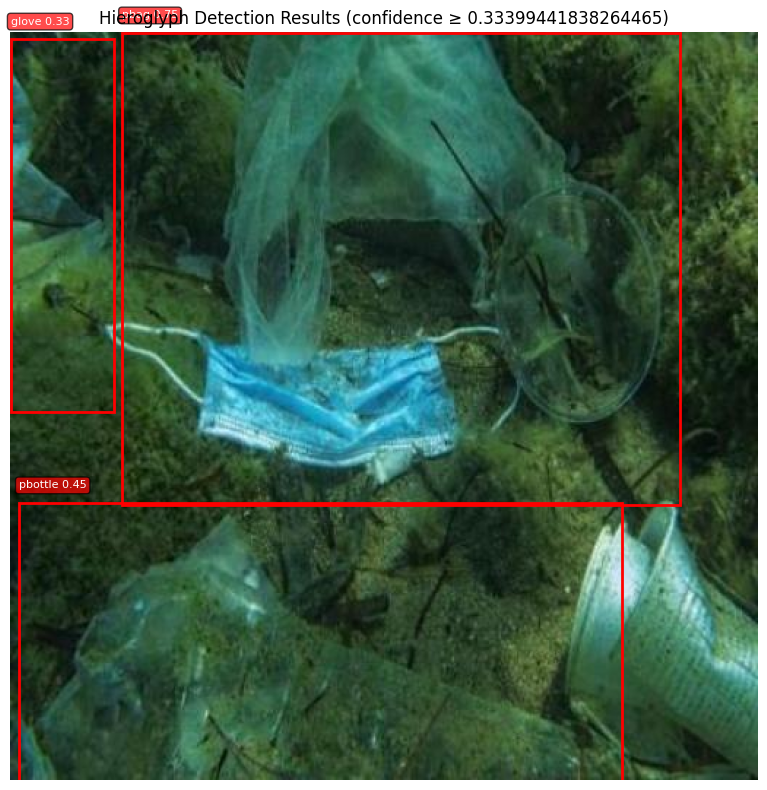

🔍 Detected 3 objects in the test image


In [ ]:
import cv2
import numpy as np

def test_and_visualize(model, image_path, confidence=0.3):
    """Test model and visualize results with bounding boxes"""
    
    # Run prediction
    results = model.predict(image_path, conf=confidence)
    
    # Load original image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Create plot
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    
    # Plot bounding boxes
    for box in results[0].boxes:
        # Get box coordinates
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        
        # Draw rectangle
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                        fill=False, edgecolor='red', linewidth=2))
        # Add label
        plt.text(x1, y1-10, f'{class_name} {confidence:.2f}', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.7),
                fontsize=8, color='white')
    
    plt.axis('off')
    plt.title(f'Detection Results (confidence ≥ {confidence})')
    plt.tight_layout()
    plt.show()
    
    return len(results[0].boxes)

# Test the function
test_image = 'Datasets/under water debris detection.v1i.yolov8/test/images/GettyImages-1227891345-1000x667_jpg.rf.f2da3b84c768edb8d0f6e29d966cc9c7.jpg'  # Replace with actual path
detections = test_and_visualize(fine_tuned_model, test_image)
print(f"Detected {detections} objects in the test image")